In [1]:
!pip -q install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00


In [2]:
!pip -q install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 49.6 MB/s eta 0:00:00


In [3]:
import numpy as np 
import pandas as pd

import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.data import Batch

import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
print("RDKit version:", rdkit.__version__)

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

RDKit version: 2025.09.4
/kaggle/input/donor-acceptor/Active_Database.csv


In [4]:
# SET ALL SEEDS FOR MODEL
seed = 42


np.random.seed(seed)

# Disables string/object hash randomization to ensure consistent 
# dict/set ordering and reproducible data shuffling across runs.
os.environ["PYTHONHASHSEED"] = str(seed)

# Torch specific
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # for multi-GPU

# Ensure deterministic behavior in cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# Example Kaggle input path:
DATA_PATH = "/kaggle/input/donor-acceptor/Active_Database.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1")
print(df.shape)
df.head()

(2439, 18)


,Checked,DOI,Donor,Acceptor,Donor SMILES,Acceptor SMILES,Voc,Jsc,FF,PCE,HOMO_A,LUMO_A,Ehl_A,Eg_A,HOMO_D,LUMO_D,Ehl_D,Eg_D
0,YES,10.1002/aenm.201703291,PBFSF,N2200,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,0.83,11.95,0.61,6.00,-5.71,-4.02,1.69,NaN,-5.27,-3.72,1.55,NaN
1,YES,10.1002/aenm.201703291,PBBSB,N2200,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,0.73,7.81,0.52,3.00,-5.71,-4.02,1.69,NaN,-5.19,-3.63,1.56,NaN
2,YES,10.1002/aenm.201801209,PTB7-Th,IOTIC-2F,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(C=C4...,0.817,21.90,0.65,12.10,-5.34,-4.06,1.28,1.31,-5.21,-3.60,1.61,1.58
3,YES,10.1002/aenm.201901024,PTB7-Th,3TT-CIC,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,0.65,26.67,0.69,11.96,-5.24,-3.95,1.29,1.23,-5.21,-3.60,1.61,1.58
4,YES,10.1002/adma.201706816,PTB7-Th,6TBA,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,0.98,15.20,0.68,10.13,-5.24,-3.78,1.46,NaN,-5.21,-3.60,1.61,1.58


In [6]:
# keep only verified rows
df = df[df["Checked"].astype(str).str.upper() == "YES"].copy()

required = ["Donor SMILES", "Acceptor SMILES", "HOMO_D", "LUMO_D", "HOMO_A", "LUMO_A"]
df = df.dropna(subset=required)

# remove duplicate donor-acceptor pairs
df = df.drop_duplicates(subset=["Donor SMILES", "Acceptor SMILES"]).reset_index(drop=True)

print("After cleaning:", df.shape)
df.head()

After cleaning: (1776, 18)


,Checked,DOI,Donor,Acceptor,Donor SMILES,Acceptor SMILES,Voc,Jsc,FF,PCE,HOMO_A,LUMO_A,Ehl_A,Eg_A,HOMO_D,LUMO_D,Ehl_D,Eg_D
0,YES,10.1002/aenm.201703291,PBFSF,N2200,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,0.83,11.95,0.61,6.00,-5.71,-4.02,1.69,NaN,-5.27,-3.72,1.55,NaN
1,YES,10.1002/aenm.201703291,PBBSB,N2200,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,0.73,7.81,0.52,3.00,-5.71,-4.02,1.69,NaN,-5.19,-3.63,1.56,NaN
2,YES,10.1002/aenm.201801209,PTB7-Th,IOTIC-2F,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(C=C4...,0.817,21.90,0.65,12.10,-5.34,-4.06,1.28,1.31,-5.21,-3.60,1.61,1.58
3,YES,10.1002/aenm.201901024,PTB7-Th,3TT-CIC,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,0.65,26.67,0.69,11.96,-5.24,-3.95,1.29,1.23,-5.21,-3.60,1.61,1.58
4,YES,10.1002/adma.201706816,PTB7-Th,6TBA,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,0.98,15.20,0.68,10.13,-5.24,-3.78,1.46,NaN,-5.21,-3.60,1.61,1.58


In [7]:
# physics-inspired deltas
df["dHOMO"] = pd.to_numeric(df["HOMO_D"], errors="coerce") - pd.to_numeric(df["HOMO_A"], errors="coerce")
df["dLUMO"] = pd.to_numeric(df["LUMO_A"], errors="coerce") - pd.to_numeric(df["LUMO_D"], errors="coerce")

# make sure target cols are numeric
maybe_scale = ["dHOMO", "dLUMO", "Voc", "PCE"]
cols_to_scale = [c for c in maybe_scale if c in df.columns]

for c in cols_to_scale:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows where any scale-column is still missing
df = df.dropna(subset=cols_to_scale).reset_index(drop=True)


df[cols_to_scale].describe()


,dHOMO,dLUMO,Voc,PCE
count,1775.000000,1775.000000,1775.000000,1775.000000
mean,0.282217,-0.452132,0.878877,8.099762
std,0.249416,0.264516,0.125197,3.924389
min,-0.290000,-1.620000,0.220000,0.010000
25%,0.116000,-0.600000,0.817000,5.400000
50%,0.226000,-0.430000,0.890000,8.540000
75%,0.380000,-0.280000,0.950000,10.975000
max,1.410000,0.750000,1.340000,18.770000


In [8]:
df["Donor_mol"] = df["Donor SMILES"].apply(Chem.MolFromSmiles)
df["Acceptor_mol"] = df["Acceptor SMILES"].apply(Chem.MolFromSmiles)

before = len(df)
df = df.dropna(subset=["Donor_mol", "Acceptor_mol"]).reset_index(drop=True)
after = len(df)

print(f"Dropped invalid SMILES rows: {before-after}")
print("Remaining:", df.shape)

Dropped invalid SMILES rows: 1
Remaining: (1774, 22)


[23:25:02] SMILES Parse Error: syntax error while parsing: 
[23:25:02] SMILES Parse Error: check for mistakes around position 1:
[23:25:02] 
[23:25:02] ^
[23:25:02] SMILES Parse Error: Failed parsing SMILES ' ' for input: ' '


In [9]:
df["Donor_MW"] = df["Donor_mol"].apply(Descriptors.MolWt)
df["Acceptor_MW"] = df["Acceptor_mol"].apply(Descriptors.MolWt)

df[["Donor_MW", "Acceptor_MW"]].describe()

,Donor_MW,Acceptor_MW
count,1774.000000,1774.000000
mean,1072.418767,1535.495724
std,355.004148,497.320416
min,168.305000,250.300000
25%,919.463000,1379.867250
50%,1213.976000,1468.096000
75%,1249.956000,1681.636250
max,2603.610000,6987.510000


In [10]:
HYB_MAP = {
    Chem.rdchem.HybridizationType.SP: 0,
    Chem.rdchem.HybridizationType.SP2: 1,
    Chem.rdchem.HybridizationType.SP3: 2,
    Chem.rdchem.HybridizationType.SP3D: 3,
    Chem.rdchem.HybridizationType.SP3D2: 4,
}

def smiles_to_graph(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features (all numeric)
    node_feats = []
    for atom in mol.GetAtoms():
        node_feats.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            HYB_MAP.get(atom.GetHybridization(), -1),
            int(atom.GetIsAromatic())
        ])
    x = torch.tensor(node_feats, dtype=torch.float)

    # Edges
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)

In [11]:
df["donor_graph"] = df["Donor SMILES"].apply(smiles_to_graph)
df["acceptor_graph"] = df["Acceptor SMILES"].apply(smiles_to_graph)

before = len(df)
df = df.dropna(subset=["donor_graph", "acceptor_graph"]).reset_index(drop=True)
after = len(df)

print(f"Dropped graph build failures: {before-after}")
print("Final rows:", df.shape)

# quick sanity check
df.loc[0, "donor_graph"]

Dropped graph build failures: 0
Final rows: (1774, 26)


Data(x=[93, 5], edge_index=[2, 208])

In [12]:
PAIR_COLS = ["dHOMO", "dLUMO", "Donor_MW", "Acceptor_MW"]
TARGET_COL = "PCE"

# keep only what training uses + SMILES for sanity checks / no-leak split
KEEP_COLS = [
    "Donor SMILES", "Acceptor SMILES",
    "donor_graph", "acceptor_graph",
] + PAIR_COLS + [TARGET_COL]

# ensure numeric
for c in PAIR_COLS + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows missing required data
df = df.dropna(subset=KEEP_COLS).reset_index(drop=True)

# drop all other columns
df = df.loc[:, KEEP_COLS].copy()

print("Final training df shape:", df.shape)
df.head()


Final training df shape: (1774, 9)


,Donor SMILES,Acceptor SMILES,donor_graph,acceptor_graph,dHOMO,dLUMO,Donor_MW,Acceptor_MW,PCE
0,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.44,-0.30,1412.272,991.546,6.00
1,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.52,-0.39,1376.292,991.546,3.00
2,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(C=C4...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.13,-0.46,919.463,1772.470,12.10
3,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.03,-0.35,919.463,1627.882,11.96
4,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.03,-0.18,919.463,1502.242,10.13


In [13]:
#CHECKPOINT THE DF IF FOOBAR
checkpoint = df.copy()
checkpoint.head()

,Donor SMILES,Acceptor SMILES,donor_graph,acceptor_graph,dHOMO,dLUMO,Donor_MW,Acceptor_MW,PCE
0,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.44,-0.30,1412.272,991.546,6.00
1,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.52,-0.39,1376.292,991.546,3.00
2,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(C=C4...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.13,-0.46,919.463,1772.470,12.10
3,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.03,-0.35,919.463,1627.882,11.96
4,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.03,-0.18,919.463,1502.242,10.13


In [14]:
#RUN THIS BLOCK TO RESET BACK TO OG DATAFRAME
df = checkpoint.copy()
df.head()

,Donor SMILES,Acceptor SMILES,donor_graph,acceptor_graph,dHOMO,dLUMO,Donor_MW,Acceptor_MW,PCE
0,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.44,-0.30,1412.272,991.546,6.00
1,CCCCCCC(CCCC)CC1=CC=C(C2=C3SC=CC3=C(C3=CC=C(CC...,CCCCCCCCCCC(CCCCCCCC)CN1C(=O)C2=C3C(=CC(C4=CC=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.52,-0.39,1376.292,991.546,3.00
2,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(C=C4...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.13,-0.46,919.463,1772.470,12.10
3,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.03,-0.35,919.463,1627.882,11.96
4,CCCCC(CC)COC(=O)c1sc2c(-c3cc4c(-c5ccc(CC(CC)CC...,CCCCCCC1=CC=C(C2(C3=CC=C(CCCCCC)C=C3)C3=C(SC4=...,"[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....","[(x, [tensor([6., 1., 0., 2., 0.]), tensor([6....",0.03,-0.18,919.463,1502.242,10.13


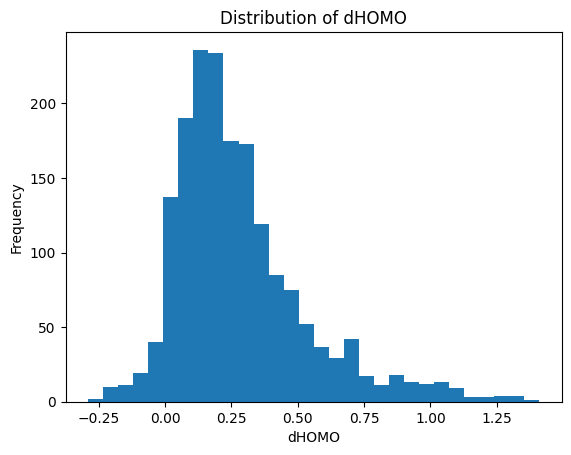

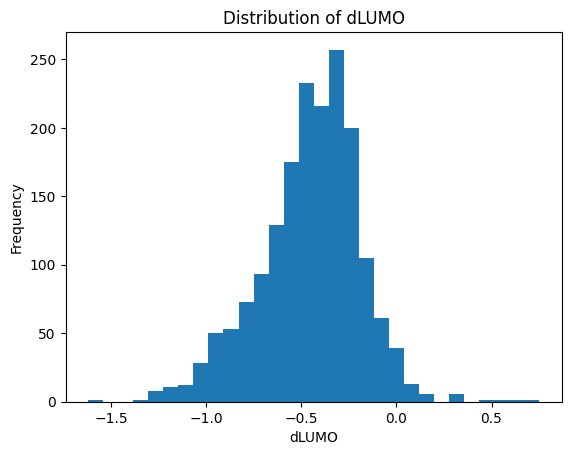

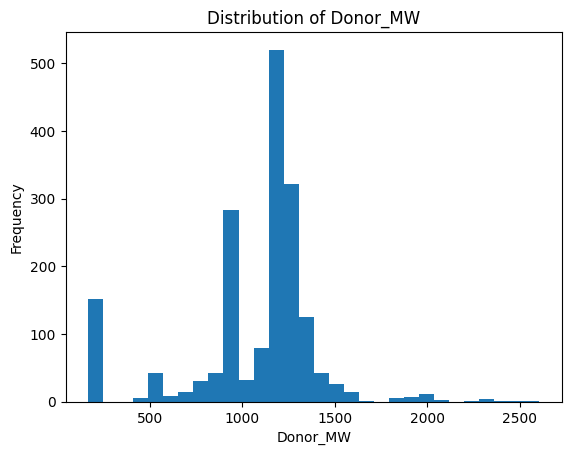

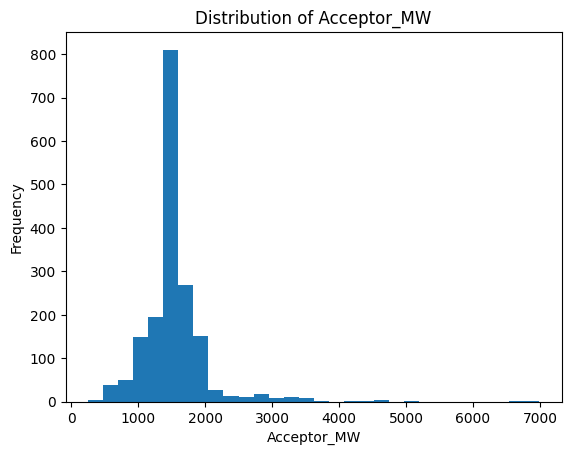

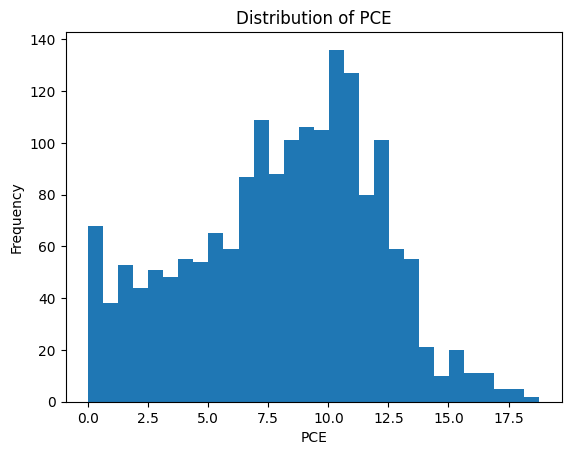

In [15]:
# GENERATE GRAPHS
# Columns to plot
columns = [
    "dHOMO",
    "dLUMO",
    "Donor_MW",
    "Acceptor_MW",
    "PCE"
]

# Histogram plots
for col in columns:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()


In [16]:
# Columns to plot
columns = [
    "dHOMO",
    "dLUMO",
    "Donor_MW",
    "Acceptor_MW",
    "PCE"
]

#Log tranform and standard scaler over Donor_MW and Acceptor_MW
#Clip outliers +-3 std
# def preprocess_data(clip=False):
#     df["Donor_MW"] = np.log1p(df["Donor_MW"])
#     df["Acceptor_MW"] = np.log1p(df["Acceptor_MW"])
    
#     scaler = StandardScaler()
#     df[["Donor_MW", "Acceptor_MW"]] = scaler.fit_transform(
#         df[["Donor_MW", "Acceptor_MW"]]
#     )
    

#     if not clip:
#         return
    
#     for col in columns:
#         df[col] = df[col].clip(-3, 3)


# WE NEED THIS TO INVERSE TRANSFORM PCE LATER
PCE_scaler = StandardScaler()
def preprocess_data(df):
    df = df.copy()

    df["PCE"] = np.log1p(df["PCE"])
    df[["PCE"]] = PCE_scaler.fit_transform(df[["PCE"]])
    
    
    # MW
    mw_cols = ["Donor_MW", "Acceptor_MW"]
    df[mw_cols] = np.log1p(df[mw_cols])
    df[mw_cols] = StandardScaler().fit_transform(df[mw_cols])


    # Energies (robust)
    energy_cols = ["dHOMO", "dLUMO"]
    df[energy_cols] = RobustScaler(quantile_range=(5, 95)).fit_transform(
        df[energy_cols]
    )

    return df
    

In [17]:
# DESCRIBE ALL COLUMNS before preprocessing
print("*"*25,"BEFORE","*"*25)
for col in columns:
    print("*"*10,col,"*"*10)
    print(df[col].describe())



# DESCRIBE ALL COLUMNS after preprocessing
df = preprocess_data(df)
print("*"*25,"AFTER","*"*25)
for col in columns:
    print("*"*10,col,"*"*10)
    print(df[col].describe())

************************* BEFORE *************************
********** dHOMO **********
count    1774.000000
mean        0.282213
std         0.249486
min        -0.290000
25%         0.116000
50%         0.226000
75%         0.380000
max         1.410000
Name: dHOMO, dtype: float64
********** dLUMO **********
count    1774.000000
mean       -0.452127
std         0.264591
min        -1.620000
25%        -0.600000
50%        -0.428500
75%        -0.280000
max         0.750000
Name: dLUMO, dtype: float64
********** Donor_MW **********
count    1774.000000
mean     1072.418767
std       355.004148
min       168.305000
25%       919.463000
50%      1213.976000
75%      1249.956000
max      2603.610000
Name: Donor_MW, dtype: float64
********** Acceptor_MW **********
count    1774.000000
mean     1535.495724
std       497.320416
min       250.300000
25%      1379.867250
50%      1468.096000
75%      1681.636250
max      6987.510000
Name: Acceptor_MW, dtype: float64
********** PCE **********
c

In [18]:
class PairDataset(Dataset):
    def __init__(self, df, indices, pair_cols, target_col):
        self.df = df
        self.indices = indices
        self.pair_cols = pair_cols
        self.target_col = target_col

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        row = self.df.iloc[self.indices[i]]

        donor = row["donor_graph"]
        acceptor = row["acceptor_graph"]

        pair_feats = torch.tensor(row[self.pair_cols].values.astype(np.float32))
        y = torch.tensor([float(row[self.target_col])], dtype=torch.float32)

        return donor, acceptor, pair_feats, y

def collate_pairs(batch):
    donors, acceptors, pair_feats, ys = zip(*batch)
    donor_batch = Batch.from_data_list(list(donors))
    acceptor_batch = Batch.from_data_list(list(acceptors))
    pair_feats = torch.stack(pair_feats, dim=0)
    ys = torch.cat(ys, dim=0)  # shape [B]
    return donor_batch, acceptor_batch, pair_feats, ys


In [19]:
#TRAIN TEST VAL SPLIT
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, random_state=42, shuffle=True)

train_ds = PairDataset(df, train_idx, PAIR_COLS, TARGET_COL)
val_ds   = PairDataset(df, val_idx,   PAIR_COLS, TARGET_COL)
test_ds  = PairDataset(df, test_idx,  PAIR_COLS, TARGET_COL)
BATCH_SIZE=32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_pairs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_pairs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_pairs)

In [20]:
class MolEncoder(nn.Module):
    """
    Encodes a molecular graph (PyG Batch of Data objects) into a graph embedding.
    """
    def __init__(self, in_dim=5, hidden_dim=64, out_dim=128, dropout=0.1):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # graph-level embedding
        g = global_mean_pool(x, batch)   # [batch_size, out_dim]
        return g


class DonorAcceptorModel(nn.Module):
    """
    Siamese GNN:
      donor_graph -> donor embedding
      acceptor_graph -> acceptor embedding
      concat([donor_emb, acceptor_emb, pair_feats]) -> MLP -> y
    """
    def __init__(
        self,
        node_feat_dim=5,
        pair_feat_dim=4,      # <- dHOMO, dLUMO, Donor_MW, Acceptor_MW
        emb_dim=128,
        gnn_hidden=64,
        mlp_hidden=128,
        out_dim=1,
        dropout=0.2
    ):
        super().__init__()

        self.d_enc = MolEncoder(in_dim=node_feat_dim, hidden_dim=gnn_hidden, out_dim=emb_dim, dropout=dropout)
        self.a_enc = MolEncoder(in_dim=node_feat_dim, hidden_dim=gnn_hidden, out_dim=emb_dim, dropout=dropout)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2 + pair_feat_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden // 2, out_dim),
        )

    def forward(self, donor_batch, acceptor_batch, pair_feats):
        """
        donor_batch: PyG Batch
        acceptor_batch: PyG Batch
        pair_feats: torch.FloatTensor [B, pair_feat_dim]
        """
        h_donor = self.d_enc(donor_batch)         # [B, emb_dim]
        h_acceptor = self.a_enc(acceptor_batch)   # [B, emb_dim]

        # concat donor+acceptor embeddings + pair features
        h = torch.cat([h_donor, h_acceptor, pair_feats], dim=1)  # [B, 2*emb_dim + pair_feat_dim]
        out = self.mlp(h)  # [B, out_dim]
        return out


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = DonorAcceptorModel(
    node_feat_dim=5,
    pair_feat_dim=len(PAIR_COLS),
    emb_dim=128,
    gnn_hidden=64,
    mlp_hidden=128,
    out_dim=1,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()


device: cpu


In [22]:
def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    preds_all = []
    ys_all = []

    for donor_batch, acceptor_batch, pair_feats, ys in loader:
        donor_batch = donor_batch.to(device)
        acceptor_batch = acceptor_batch.to(device)
        pair_feats = pair_feats.to(device)
        ys = ys.to(device)

        if train:
            optimizer.zero_grad()

        out = model(donor_batch, acceptor_batch, pair_feats).squeeze(1)  # [B]
        loss = loss_fn(out, ys)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()

        total_loss += loss.item() * ys.size(0)

        preds_all.append(out.detach().cpu())
        ys_all.append(ys.detach().cpu())

    preds_all = torch.cat(preds_all)
    ys_all = torch.cat(ys_all)

    mse = torch.mean((preds_all - ys_all) ** 2).item()
    rmse = float(torch.sqrt(torch.tensor(mse)))
    mae = torch.mean(torch.abs(preds_all - ys_all)).item()

    return total_loss / len(loader.dataset), rmse, mae


In [23]:
EPOCHS = 20

for epoch in range(1, EPOCHS + 1):
    train_loss, train_rmse, train_mae = run_epoch(model, train_loader, train=True)
    val_loss, val_rmse, val_mae = run_epoch(model, val_loader, train=False)

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss {train_loss:.4f} RMSE {train_rmse:.4f} MAE {train_mae:.4f} | "
        f"Val loss {val_loss:.4f} RMSE {val_rmse:.4f} MAE {val_mae:.4f}"
    )


Epoch 01 | Train loss 0.8707 RMSE 0.9331 MAE 0.7060 | Val loss 0.9498 RMSE 0.9746 MAE 0.6981
Epoch 02 | Train loss 0.6799 RMSE 0.8246 MAE 0.6049 | Val loss 0.7357 RMSE 0.8578 MAE 0.6468
Epoch 03 | Train loss 0.6293 RMSE 0.7933 MAE 0.5722 | Val loss 0.7042 RMSE 0.8392 MAE 0.6226
Epoch 04 | Train loss 0.5917 RMSE 0.7692 MAE 0.5532 | Val loss 0.7214 RMSE 0.8493 MAE 0.6048
Epoch 05 | Train loss 0.5826 RMSE 0.7633 MAE 0.5467 | Val loss 0.7291 RMSE 0.8539 MAE 0.6459
Epoch 06 | Train loss 0.5739 RMSE 0.7575 MAE 0.5453 | Val loss 0.6758 RMSE 0.8221 MAE 0.5933
Epoch 07 | Train loss 0.5769 RMSE 0.7595 MAE 0.5445 | Val loss 0.6744 RMSE 0.8212 MAE 0.5882
Epoch 08 | Train loss 0.5608 RMSE 0.7489 MAE 0.5379 | Val loss 0.6739 RMSE 0.8209 MAE 0.6126
Epoch 09 | Train loss 0.5627 RMSE 0.7501 MAE 0.5325 | Val loss 0.6852 RMSE 0.8278 MAE 0.6369
Epoch 10 | Train loss 0.5559 RMSE 0.7456 MAE 0.5370 | Val loss 0.7059 RMSE 0.8402 MAE 0.6767
Epoch 11 | Train loss 0.5414 RMSE 0.7358 MAE 0.5326 | Val loss 0.6408 

In [24]:
def eval_metrics(y_pred, y_true):
    # Ensure 1D tensors
    if not isinstance(y_pred, torch.Tensor):
        y_pred = torch.tensor(y_pred)

    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true)
        
    y_pred = y_pred.view(-1)
    y_true = y_true.view(-1)

    # Remove NaNs if any
    mask = torch.isfinite(y_pred) & torch.isfinite(y_true)
    y_pred = y_pred[mask]
    y_true = y_true[mask]


    rmse = torch.sqrt(F.mse_loss(y_pred, y_true))

    mae = F.l1_loss(y_pred, y_true)

    vx = y_pred - y_pred.mean()
    vy = y_true - y_true.mean()
    pearson = (vx * vy).sum() / (
        torch.sqrt((vx**2).sum()) * torch.sqrt((vy**2).sum()) + 1e-8
    )
    
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - y_true.mean()) ** 2) + 1e-8
    r2 = 1 - ss_res / ss_tot

    return {
        "RMSE": rmse.item(),
        "MAE": mae.item(),
        "PearsonR": pearson.item(),
        "R2": r2.item()
    }


In [25]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds_all, ys_all = [], []

    for donor_batch, acceptor_batch, pair_feats, ys in loader:
        donor_batch = donor_batch.to(device)
        acceptor_batch = acceptor_batch.to(device)
        pair_feats = pair_feats.to(device)
        ys = ys.to(device)

        out = model(donor_batch, acceptor_batch, pair_feats).squeeze(1)

        preds_all.append(out.cpu())
        ys_all.append(ys.cpu())

    return torch.cat(preds_all), torch.cat(ys_all)


In [26]:
def get_og(preds):
    preds_np = preds.detach().cpu().numpy()
    pce_back = PCE_scaler.inverse_transform(preds_np.reshape(-1, 1))
    pce_back = np.expm1(pce_back)

    return pce_back

In [27]:
val_pred, val_true = predict_loader(model, test_loader)
val_pred = get_og(val_pred)
val_true = get_og(val_true)

print(eval_metrics(val_pred, val_true))

{'RMSE': 3.1129276752471924, 'MAE': 2.4839487075805664, 'PearsonR': 0.7206816077232361, 'R2': 0.39406895637512207}
